# Experiment 3 — Full Evaluation, top_k Tuning & Visualizations
**Query dataset:** Dataset 1 (all recoverable rows)  
**Knowledge base:** Datasets 2, 3, 4  
**LLM:** Llama 3.1 8B via Ollama (local)  
**Configs:** LLM-only | RAG-full (top_k=1,3,5) | RAG-partial (50%)

## 1. Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

sns.set_theme(style="whitegrid", palette="muted")
SAVE_FIGS = True  # set False to only display, not save

## 2. Load Datasets

In [10]:
df1 = pd.read_json("normalized_products/dataset_1_normalized.json")
df2 = pd.read_json("normalized_products/dataset_2_normalized.json")
df3 = pd.read_json("normalized_products/dataset_3_normalized.json")
df4 = pd.read_json("normalized_products/dataset_4_normalized.json")

kb_full = pd.concat([df2, df3, df4], ignore_index=True)
kb_partial = kb_full.sample(frac=0.5, random_state=42).reset_index(drop=True)

print(f"Dataset 1 (query): {len(df1)} rows")
print(f"Knowledge base (full): {len(kb_full)} rows")
print(f"Knowledge base (50%):  {len(kb_partial)} rows")

Dataset 1 (query): 812 rows
Knowledge base (full): 2200 rows
Knowledge base (50%):  1100 rows


## 3. Build Full Evaluation Set

In [11]:
TARGET_ATTRIBUTES = [
    "model_number",
    "bus_type",
    "interface_type",
    "form_factor",
    "storage_connection_type"
]

def get_ground_truth(cluster_id, attribute, kb):
    matches = kb[kb["cluster_id"] == cluster_id]
    for _, row in matches.iterrows():
        val = row.get(attribute)
        if pd.notna(val) and str(val).strip().lower() not in {"", "none", "nan"}:
            return str(val).strip()
    return None

eval_records = []
for idx, row in df1.iterrows():
    for attr in TARGET_ATTRIBUTES:
        if pd.isna(row.get(attr)):
            gt = get_ground_truth(row["cluster_id"], attr, kb_full)
            if gt is not None:
                eval_records.append({
                    "df1_idx": idx,
                    "cluster_id": row["cluster_id"],
                    "attribute": attr,
                    "ground_truth": gt
                })

eval_df = pd.DataFrame(eval_records)
print(f"Full eval set: {len(eval_df)} attribute-level tasks")
print(eval_df["attribute"].value_counts())

Full eval set: 627 attribute-level tasks
attribute
model_number               302
bus_type                   154
interface_type              64
form_factor                 61
storage_connection_type     46
Name: count, dtype: int64


## 4. LLM Wrapper (Ollama)

In [12]:
class OllamaLLMWrapper:
    def __init__(self, model_name="llama3.1:8b", base_url="http://localhost:11434"):
        self.model_name = model_name
        self.base_url = base_url

    def generate(self, prompt):
        response = requests.post(
            f"{self.base_url}/api/generate",
            json={"model": self.model_name, "prompt": prompt, "stream": False}
        )
        return response.json()["response"]

llm = OllamaLLMWrapper("llama3.1:8b")
print("Ollama OK:", repr(llm.generate("Say OK")[:30]))

Ollama OK: 'OK'


## 5. Cleaner Classes

In [13]:
_EMPTY = {"none", "nan", "null", "n/a", "na", "unknown", ""}

def parse_response(response):
    for line in response.splitlines():
        line = line.strip()
        if line.upper().startswith("VALUE:"):
            value = line.split(":", 1)[1].strip().strip('"').strip("'")
            if value.lower() not in _EMPTY:
                return value
    cleaned = response.strip().strip('"').strip("'")
    if cleaned and "\n" not in cleaned and len(cleaned) < 50:
        if cleaned.lower() not in _EMPTY:
            return cleaned
    return "UNKNOWN"


class LLMOnlyCleaner:
    def __init__(self, llm):
        self.llm = llm

    def clean_cell(self, row, attribute):
        product = {k: v for k, v in row.items()
                   if k in ["title", "model", "brand", "product_type"] and pd.notna(v)}
        prompt = (
            f"You are a product data expert. Fill in the missing attribute.\n\n"
            f"PRODUCT: {product}\n\n"
            f"MISSING ATTRIBUTE: {attribute}\n\n"
            f"Respond with VALUE:<answer> only. Example: VALUE:PCIe"
        )
        return parse_response(self.llm.generate(prompt))


class RAGCleaner:
    def __init__(self, knowledge_base, llm, top_k=3,
                 retriever_model="sentence-transformers/all-MiniLM-L6-v2"):
        self.kb = knowledge_base.reset_index(drop=True)
        self.llm = llm
        self.top_k = top_k
        self.model = SentenceTransformer(retriever_model)
        print(f"Encoding KB ({len(self.kb)} rows)...")
        self.kb["_text"] = self.kb.apply(self._row_to_text, axis=1)
        self.kb_embeddings = self.model.encode(
            self.kb["_text"].tolist(), convert_to_tensor=True,
            batch_size=64, show_progress_bar=True
        )
        print("KB ready.")

    def _row_to_text(self, row):
        attrs = ["title", "model", "model_number", "brand", "product_type"]
        return " | ".join([str(row[a]) for a in attrs if pd.notna(row.get(a))])

    def _build_prompt(self, row, candidates, attribute):
        product = {k: v for k, v in row.items()
                if k in ["title", "model", "brand", "product_type"] and pd.notna(row.get(k))}
        key_fields = ["title", "model", "model_number", "bus_type",
                    "interface_type", "form_factor", "storage_connection_type"]
        cands_lines = []
        for _, c in candidates.iterrows():
            c_dict = {k: v for k, v in c.items() if k in key_fields and pd.notna(c.get(k))}
            cands_lines.append(str(c_dict))
        cands_text = "\n".join(cands_lines)
        return (
            f"You are a product data expert. Fill in the missing attribute.\n\n"
            f"PRODUCT: {product}\n\n"
            f"SIMILAR REFERENCE PRODUCTS:\n{cands_text}\n\n"
            f"MISSING ATTRIBUTE: {attribute}\n\n"
            f"Respond with VALUE:<answer> only. Example: VALUE:PCIe"
        )

## 6. Evaluation Runner

In [14]:
def normalize(val):
    return str(val).lower().strip()

def is_correct(predicted, ground_truth):
    p, g = normalize(predicted), normalize(ground_truth)
    return p == g or p in g or g in p

def run_evaluation(eval_df, df1, cleaner, config_name, save_path=None):
    results = []
    total = len(eval_df)
    rows = [df1.loc[task["df1_idx"]] for _, task in eval_df.iterrows()]

    query_embeddings = None
    if isinstance(cleaner, RAGCleaner):
        print(f"Precomputing query embeddings for [{config_name}]...")
        query_texts = [cleaner._row_to_text(row) for row in rows]
        query_embeddings = cleaner.model.encode(
            query_texts, convert_to_tensor=True,
            batch_size=64, show_progress_bar=True
        )
        print("Done.")

    config_start = time.time()
    for i, (_, task) in enumerate(eval_df.iterrows()):
        t0 = time.time()
        row = rows[i]

        if query_embeddings is not None:
            cos_scores = util.cos_sim(query_embeddings[i], cleaner.kb_embeddings)[0]
            top_indices = np.argsort(-cos_scores.cpu().numpy())[:cleaner.top_k]
            candidates = cleaner.kb.iloc[top_indices]
            prompt = cleaner._build_prompt(row, candidates, task["attribute"])
            predicted = parse_response(cleaner.llm.generate(prompt))
        else:
            predicted = cleaner.clean_cell(row, task["attribute"])

        gt = task["ground_truth"]
        results.append({
            "config": config_name,
            "df1_idx": task["df1_idx"],
            "attribute": task["attribute"],
            "ground_truth": gt,
            "predicted": predicted,
            "correct": is_correct(predicted, gt),
            "unknown": predicted == "UNKNOWN"
        })

        if i % 10 == 0:
            elapsed_total = time.time() - config_start
            remaining = (elapsed_total / (i + 1)) * (total - i - 1)
            print(f"[{config_name}] {i+1}/{total} | "
                  f"{time.time()-t0:.2f}s | "
                  f"ETA: {remaining/60:.1f} min | "
                  f"{task['attribute']}")

    results_df = pd.DataFrame(results)
    if save_path:
        results_df.to_csv(save_path, index=False)
        print(f"✓ Saved [{config_name}] → {save_path}")
    return results_df

## 7. Run All Experiments
### 7a. LLM-only

In [15]:
results_llm = run_evaluation(
    eval_df, df1, LLMOnlyCleaner(llm), "LLM-only",
    save_path="results_exp3_llm_only.csv"
)

[LLM-only] 1/627 | 0.78s | ETA: 8.2 min | model_number
[LLM-only] 11/627 | 0.42s | ETA: 7.3 min | bus_type
[LLM-only] 21/627 | 0.92s | ETA: 8.0 min | model_number
[LLM-only] 31/627 | 0.36s | ETA: 7.9 min | bus_type
[LLM-only] 41/627 | 0.51s | ETA: 7.5 min | interface_type
[LLM-only] 51/627 | 0.86s | ETA: 7.3 min | form_factor
[LLM-only] 61/627 | 0.90s | ETA: 7.1 min | model_number
[LLM-only] 71/627 | 0.36s | ETA: 7.0 min | interface_type
[LLM-only] 81/627 | 0.41s | ETA: 6.8 min | bus_type
[LLM-only] 91/627 | 1.21s | ETA: 6.7 min | model_number
[LLM-only] 101/627 | 0.82s | ETA: 6.6 min | model_number
[LLM-only] 111/627 | 0.37s | ETA: 6.6 min | interface_type
[LLM-only] 121/627 | 0.67s | ETA: 6.5 min | model_number
[LLM-only] 131/627 | 0.71s | ETA: 6.4 min | bus_type
[LLM-only] 141/627 | 0.52s | ETA: 6.2 min | bus_type
[LLM-only] 151/627 | 0.66s | ETA: 6.0 min | model_number
[LLM-only] 161/627 | 0.37s | ETA: 5.9 min | bus_type
[LLM-only] 171/627 | 0.37s | ETA: 5.7 min | storage_connectio

### 7b. RAG full KB — top_k = 1

In [16]:
rag_k1 = RAGCleaner(knowledge_base=kb_full, llm=llm, top_k=1)
results_rag_k1 = run_evaluation(
    eval_df, df1, rag_k1, "RAG-full-k1",
    save_path="results_exp3_rag_full_k1.csv"
)

Encoding KB (2200 rows)...


Batches: 100%|██████████| 35/35 [00:04<00:00,  8.69it/s]


KB ready.
Precomputing query embeddings for [RAG-full-k1]...


Batches: 100%|██████████| 10/10 [00:00<00:00, 10.91it/s]


Done.
[RAG-full-k1] 1/627 | 2.01s | ETA: 20.9 min | model_number
[RAG-full-k1] 11/627 | 0.43s | ETA: 10.1 min | bus_type
[RAG-full-k1] 21/627 | 1.18s | ETA: 10.5 min | model_number
[RAG-full-k1] 31/627 | 0.59s | ETA: 10.4 min | bus_type
[RAG-full-k1] 41/627 | 0.37s | ETA: 9.9 min | interface_type
[RAG-full-k1] 51/627 | 1.32s | ETA: 9.4 min | form_factor
[RAG-full-k1] 61/627 | 1.32s | ETA: 9.3 min | model_number
[RAG-full-k1] 71/627 | 0.59s | ETA: 9.2 min | interface_type
[RAG-full-k1] 81/627 | 0.44s | ETA: 9.1 min | bus_type
[RAG-full-k1] 91/627 | 1.37s | ETA: 8.9 min | model_number
[RAG-full-k1] 101/627 | 1.37s | ETA: 8.8 min | model_number
[RAG-full-k1] 111/627 | 0.59s | ETA: 8.7 min | interface_type
[RAG-full-k1] 121/627 | 1.56s | ETA: 8.7 min | model_number
[RAG-full-k1] 131/627 | 1.03s | ETA: 8.5 min | bus_type
[RAG-full-k1] 141/627 | 1.16s | ETA: 8.3 min | bus_type
[RAG-full-k1] 151/627 | 1.11s | ETA: 8.1 min | model_number
[RAG-full-k1] 161/627 | 0.39s | ETA: 7.9 min | bus_type


### 7c. RAG full KB — top_k = 3

In [17]:
rag_k3 = RAGCleaner(knowledge_base=kb_full, llm=llm, top_k=3)
results_rag_k3 = run_evaluation(
    eval_df, df1, rag_k3, "RAG-full-k3",
    save_path="results_exp3_rag_full_k3.csv"
)

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: dc440108-2284-4dee-84d4-98fddd053796)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


Encoding KB (2200 rows)...


Batches: 100%|██████████| 35/35 [00:01<00:00, 20.07it/s]


KB ready.
Precomputing query embeddings for [RAG-full-k3]...


Batches: 100%|██████████| 10/10 [00:00<00:00, 21.49it/s]


Done.
[RAG-full-k3] 1/627 | 3.89s | ETA: 40.6 min | model_number
[RAG-full-k3] 11/627 | 0.43s | ETA: 16.1 min | bus_type
[RAG-full-k3] 21/627 | 1.00s | ETA: 15.3 min | model_number
[RAG-full-k3] 31/627 | 0.63s | ETA: 14.7 min | bus_type
[RAG-full-k3] 41/627 | 0.38s | ETA: 13.6 min | interface_type
[RAG-full-k3] 51/627 | 1.91s | ETA: 13.2 min | form_factor
[RAG-full-k3] 61/627 | 2.27s | ETA: 13.3 min | model_number
[RAG-full-k3] 71/627 | 0.75s | ETA: 13.2 min | interface_type
[RAG-full-k3] 81/627 | 0.39s | ETA: 13.0 min | bus_type
[RAG-full-k3] 91/627 | 1.98s | ETA: 12.9 min | model_number
[RAG-full-k3] 101/627 | 2.13s | ETA: 12.8 min | model_number
[RAG-full-k3] 111/627 | 0.40s | ETA: 12.7 min | interface_type
[RAG-full-k3] 121/627 | 2.26s | ETA: 12.7 min | model_number
[RAG-full-k3] 131/627 | 1.42s | ETA: 12.4 min | bus_type
[RAG-full-k3] 141/627 | 1.52s | ETA: 12.2 min | bus_type
[RAG-full-k3] 151/627 | 2.08s | ETA: 11.8 min | model_number
[RAG-full-k3] 161/627 | 0.44s | ETA: 11.5 mi

### 7d. RAG full KB — top_k = 5

In [18]:
rag_k5 = RAGCleaner(knowledge_base=kb_full, llm=llm, top_k=5)
results_rag_k5 = run_evaluation(
    eval_df, df1, rag_k5, "RAG-full-k5",
    save_path="results_exp3_rag_full_k5.csv"
)

Encoding KB (2200 rows)...


Batches: 100%|██████████| 35/35 [00:01<00:00, 20.06it/s]


KB ready.
Precomputing query embeddings for [RAG-full-k5]...


Batches: 100%|██████████| 10/10 [00:00<00:00, 21.31it/s]


Done.
[RAG-full-k5] 1/627 | 3.94s | ETA: 41.1 min | model_number
[RAG-full-k5] 11/627 | 0.69s | ETA: 20.8 min | bus_type
[RAG-full-k5] 21/627 | 5.79s | ETA: 22.4 min | model_number
[RAG-full-k5] 31/627 | 0.60s | ETA: 21.4 min | bus_type
[RAG-full-k5] 41/627 | 0.39s | ETA: 19.5 min | interface_type
[RAG-full-k5] 51/627 | 2.58s | ETA: 18.8 min | form_factor
[RAG-full-k5] 61/627 | 3.05s | ETA: 18.7 min | model_number
[RAG-full-k5] 71/627 | 0.45s | ETA: 18.3 min | interface_type
[RAG-full-k5] 81/627 | 0.75s | ETA: 18.0 min | bus_type
[RAG-full-k5] 91/627 | 2.75s | ETA: 17.8 min | model_number
[RAG-full-k5] 101/627 | 2.92s | ETA: 17.7 min | model_number
[RAG-full-k5] 111/627 | 0.39s | ETA: 17.4 min | interface_type
[RAG-full-k5] 121/627 | 3.30s | ETA: 17.3 min | model_number
[RAG-full-k5] 131/627 | 1.79s | ETA: 16.9 min | bus_type
[RAG-full-k5] 141/627 | 2.09s | ETA: 16.5 min | bus_type
[RAG-full-k5] 151/627 | 3.05s | ETA: 16.0 min | model_number
[RAG-full-k5] 161/627 | 0.65s | ETA: 15.6 mi

### 7e. RAG partial KB (50%) — top_k = 3

In [19]:
rag_partial = RAGCleaner(knowledge_base=kb_partial, llm=llm, top_k=3)
results_rag_partial = run_evaluation(
    eval_df, df1, rag_partial, "RAG-partial",
    save_path="results_exp3_rag_partial.csv"
)

Encoding KB (1100 rows)...


Batches: 100%|██████████| 18/18 [00:01<00:00, 13.20it/s]


KB ready.
Precomputing query embeddings for [RAG-partial]...


Batches: 100%|██████████| 10/10 [00:00<00:00, 21.09it/s]


Done.
[RAG-partial] 1/627 | 2.26s | ETA: 23.6 min | model_number
[RAG-partial] 11/627 | 0.38s | ETA: 13.7 min | bus_type
[RAG-partial] 21/627 | 1.12s | ETA: 14.1 min | model_number
[RAG-partial] 31/627 | 0.64s | ETA: 14.2 min | bus_type
[RAG-partial] 41/627 | 0.39s | ETA: 13.5 min | interface_type
[RAG-partial] 51/627 | 1.84s | ETA: 13.4 min | form_factor
[RAG-partial] 61/627 | 2.10s | ETA: 13.6 min | model_number
[RAG-partial] 71/627 | 0.44s | ETA: 13.2 min | interface_type
[RAG-partial] 81/627 | 0.44s | ETA: 13.0 min | bus_type
[RAG-partial] 91/627 | 2.03s | ETA: 12.8 min | model_number
[RAG-partial] 101/627 | 2.14s | ETA: 12.8 min | model_number
[RAG-partial] 111/627 | 0.39s | ETA: 12.7 min | interface_type
[RAG-partial] 121/627 | 2.36s | ETA: 12.7 min | model_number
[RAG-partial] 131/627 | 1.33s | ETA: 12.5 min | bus_type
[RAG-partial] 141/627 | 1.62s | ETA: 12.2 min | bus_type
[RAG-partial] 151/627 | 2.09s | ETA: 11.8 min | model_number
[RAG-partial] 161/627 | 0.44s | ETA: 11.5 mi

## 8. Combine Results

In [20]:
all_results = pd.concat([
    results_llm, results_rag_k1, results_rag_k3,
    results_rag_k5, results_rag_partial
], ignore_index=True)
all_results.to_csv("results_exp3_all.csv", index=False)

print("OVERALL ACCURACY")
print(all_results.groupby("config")["correct"].mean().round(3))
print("\nPER-ATTRIBUTE ACCURACY")
print(all_results.groupby(["config", "attribute"])["correct"].mean().round(3).unstack())
print("\nUNKNOWN RATE")
print(all_results.groupby("config")["unknown"].mean().round(3))

OVERALL ACCURACY
config
LLM-only       0.316
RAG-full-k1    0.402
RAG-full-k3    0.493
RAG-full-k5    0.557
RAG-partial    0.501
Name: correct, dtype: float64

PER-ATTRIBUTE ACCURACY
attribute    bus_type  form_factor  interface_type  model_number  \
config                                                             
LLM-only        0.773        0.115           0.438         0.066   
RAG-full-k1     0.766        0.311           0.516         0.169   
RAG-full-k3     0.786        0.426           0.594         0.308   
RAG-full-k5     0.825        0.525           0.641         0.404   
RAG-partial     0.838        0.426           0.625         0.291   

attribute    storage_connection_type  
config                                
LLM-only                       0.522  
RAG-full-k1                    0.674  
RAG-full-k3                    0.674  
RAG-full-k5                    0.587  
RAG-partial                    0.674  

UNKNOWN RATE
config
LLM-only       0.002
RAG-full-k1    0.000
RAG-

## 9. Visualizations
### 9a. Bar Chart — Overall Accuracy per Config

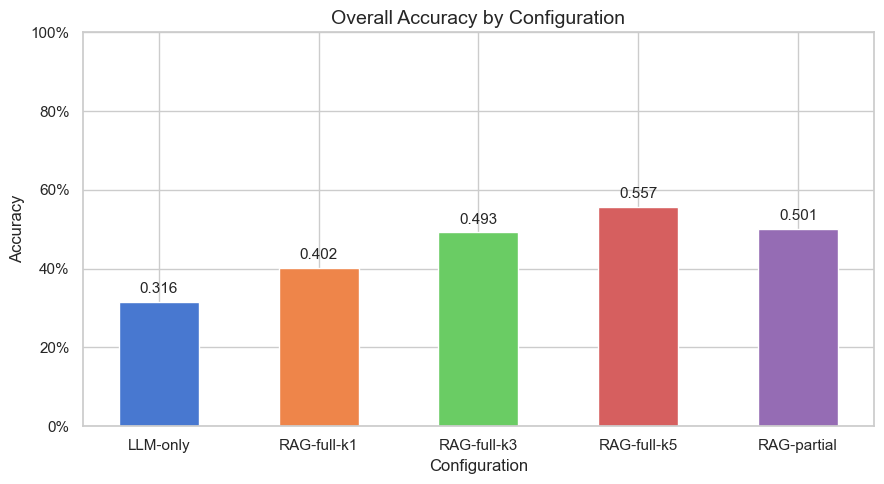

In [21]:
overall = all_results.groupby("config")["correct"].mean().reset_index()
overall.columns = ["Config", "Accuracy"]

# Consistent order
order = ["LLM-only", "RAG-full-k1", "RAG-full-k3", "RAG-full-k5", "RAG-partial"]
overall["Config"] = pd.Categorical(overall["Config"], categories=order, ordered=True)
overall = overall.sort_values("Config")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(overall["Config"], overall["Accuracy"],
              color=sns.color_palette("muted", len(overall)), edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=11)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Configuration", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Overall Accuracy by Configuration", fontsize=14)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("fig_overall_accuracy.png", dpi=150)
plt.show()

### 9b. Grouped Bar Chart — Per-Attribute Accuracy

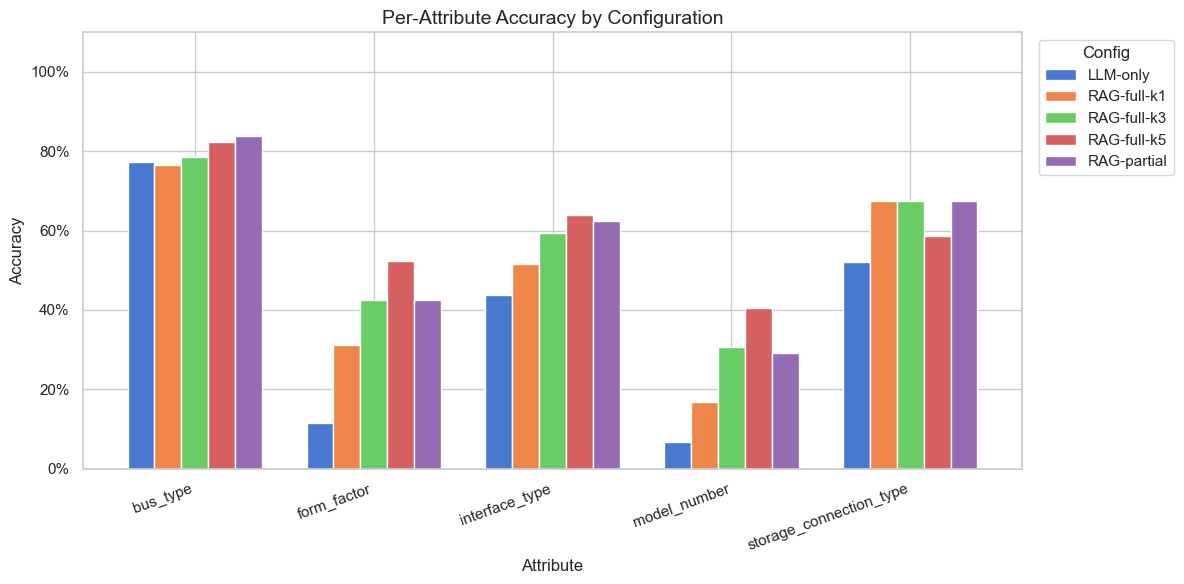

In [22]:
per_attr = all_results.groupby(["config", "attribute"])["correct"].mean().reset_index()
per_attr.columns = ["Config", "Attribute", "Accuracy"]
per_attr["Config"] = pd.Categorical(per_attr["Config"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = per_attr.pivot(index="Attribute", columns="Config", values="Accuracy")
pivot = pivot[order]  # ensure column order
pivot.plot(kind="bar", ax=ax, edgecolor="white", width=0.75)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Attribute", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Per-Attribute Accuracy by Configuration", fontsize=14)
ax.legend(title="Config", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("fig_per_attribute_accuracy.png", dpi=150)
plt.show()

### 9c. Accuracy vs KB Size (LLM-only, RAG-partial, RAG-full)

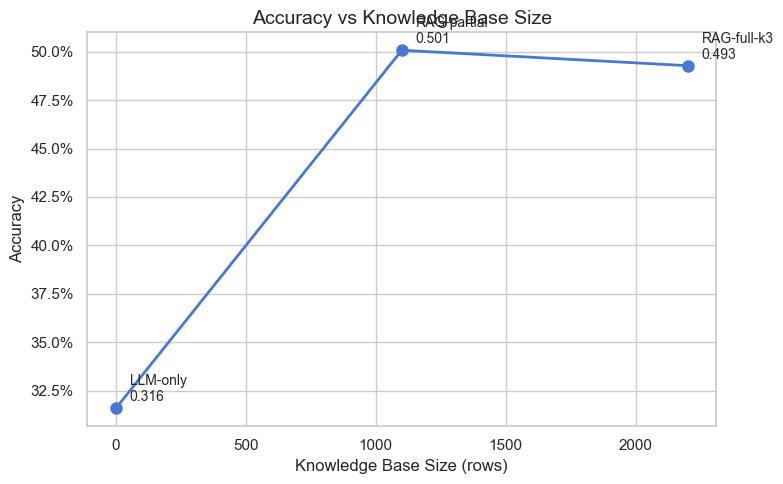

In [23]:
kb_sizes = {
    "LLM-only": 0,
    "RAG-partial": len(kb_partial),
    "RAG-full-k3": len(kb_full)
}
kb_acc = (
    all_results[all_results["config"].isin(kb_sizes.keys())]
    .groupby("config")["correct"].mean()
    .reset_index()
)
kb_acc["kb_size"] = kb_acc["config"].map(kb_sizes)
kb_acc = kb_acc.sort_values("kb_size")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kb_acc["kb_size"], kb_acc["correct"], marker="o", linewidth=2,
        markersize=8, color=sns.color_palette("muted")[0])
for _, r in kb_acc.iterrows():
    ax.annotate(f"{r['config']}\n{r['correct']:.3f}",
                (r["kb_size"], r["correct"]),
                textcoords="offset points", xytext=(10, 5), fontsize=10)
ax.set_xlabel("Knowledge Base Size (rows)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Accuracy vs Knowledge Base Size", fontsize=14)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("fig_accuracy_vs_kb_size.png", dpi=150)
plt.show()

### 9d. Confusion Matrix per Attribute (RAG-full-k3 vs LLM-only)

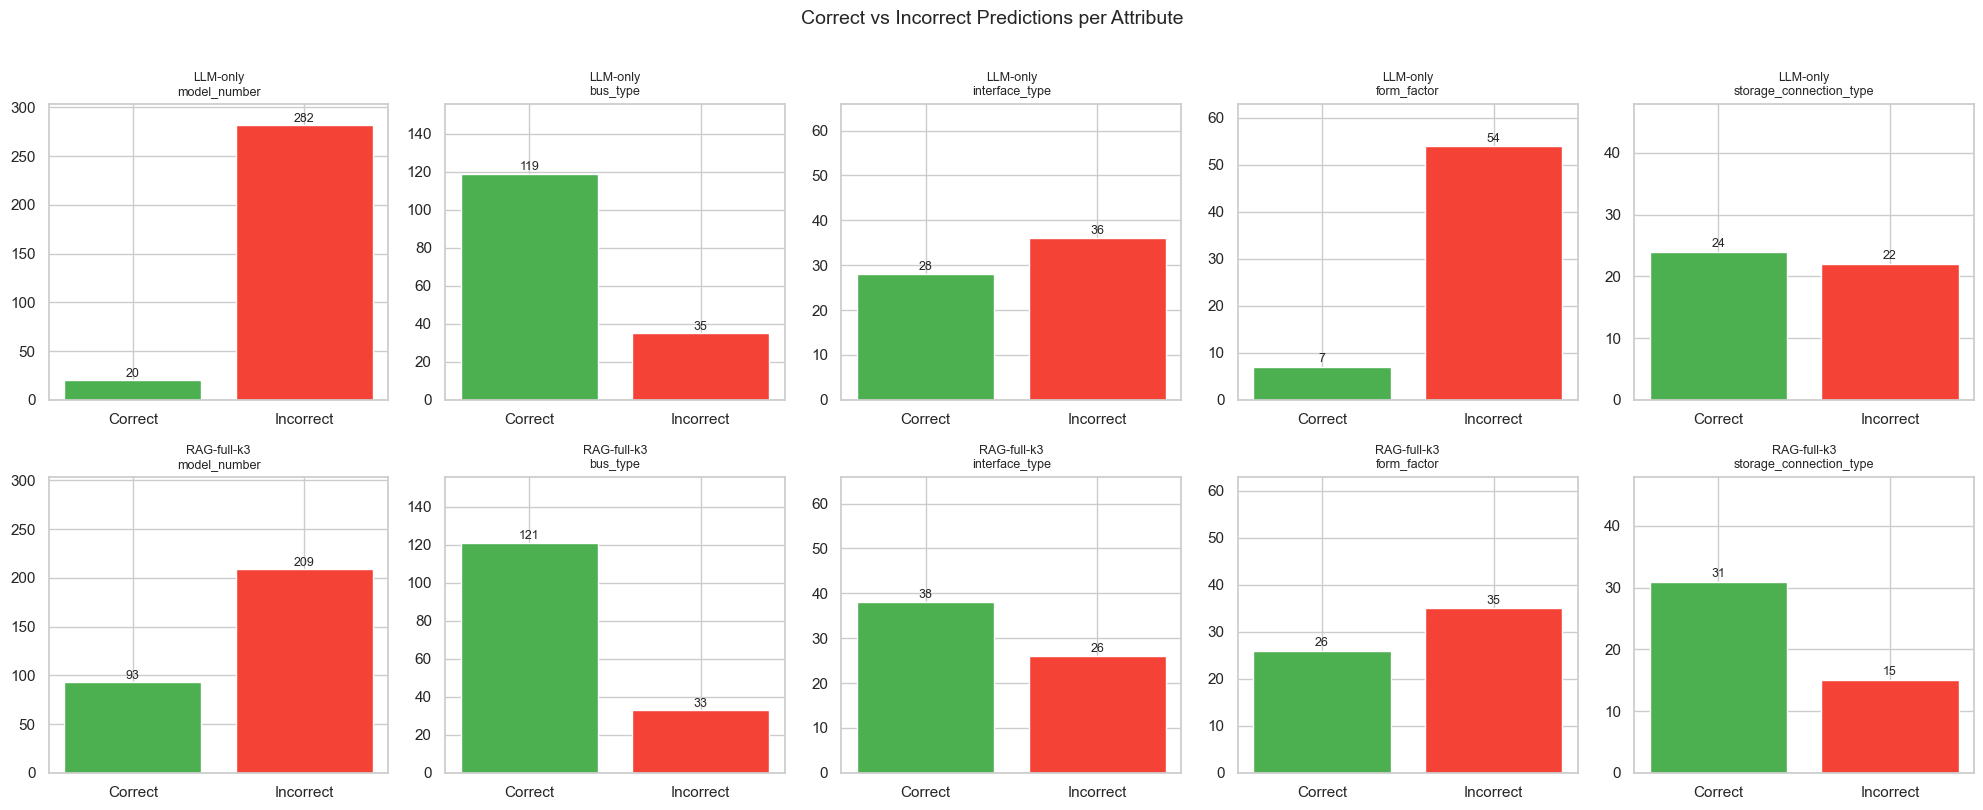

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

configs_to_compare = ["LLM-only", "RAG-full-k3"]
subset = all_results[all_results["config"].isin(configs_to_compare)]

attributes = TARGET_ATTRIBUTES
fig, axes = plt.subplots(2, len(attributes), figsize=(4 * len(attributes), 8))

for col, attr in enumerate(attributes):
    for row_idx, cfg in enumerate(configs_to_compare):
        df_sub = subset[(subset["attribute"] == attr) & (subset["config"] == cfg)]
        if len(df_sub) == 0:
            axes[row_idx][col].axis("off")
            continue
        y_true = df_sub["correct"].astype(int)
        # Binary: correct (1) vs incorrect (0)
        cm = confusion_matrix(y_true, y_true, labels=[1, 0])  # placeholder
        # Simpler: just show correct/incorrect counts as a small bar
        correct_count = df_sub["correct"].sum()
        incorrect_count = len(df_sub) - correct_count
        axes[row_idx][col].bar(["Correct", "Incorrect"],
                                [correct_count, incorrect_count],
                                color=["#4CAF50", "#F44336"], edgecolor="white")
        axes[row_idx][col].set_title(f"{cfg}\n{attr}", fontsize=9)
        axes[row_idx][col].set_ylim(0, len(df_sub) + 2)
        for bar_patch, val in zip(axes[row_idx][col].patches,
                                   [correct_count, incorrect_count]):
            axes[row_idx][col].text(
                bar_patch.get_x() + bar_patch.get_width() / 2,
                bar_patch.get_height() + 0.3,
                str(int(val)), ha="center", va="bottom", fontsize=9
            )

fig.suptitle("Correct vs Incorrect Predictions per Attribute", fontsize=14, y=1.01)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("fig_correct_incorrect_per_attribute.png", dpi=150, bbox_inches="tight")
plt.show()

### 9e. top_k Sensitivity — Accuracy vs top_k (RAG-full only)

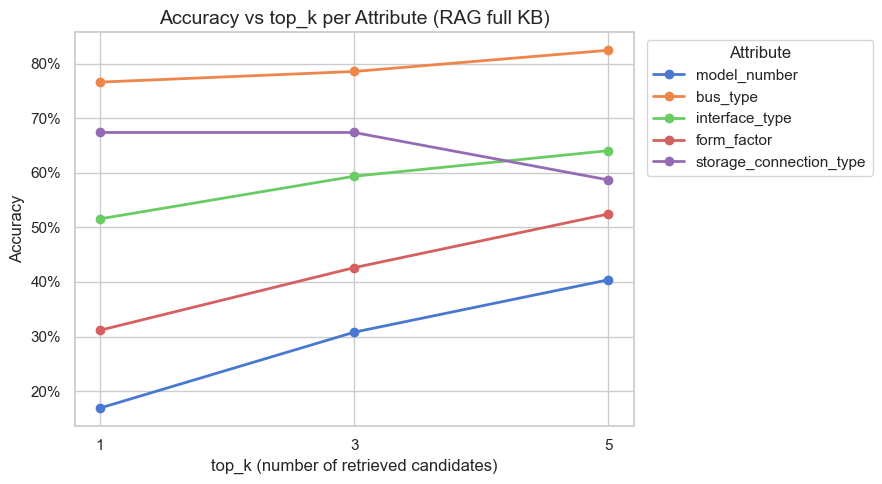

In [25]:
topk_configs = ["RAG-full-k1", "RAG-full-k3", "RAG-full-k5"]
topk_map = {"RAG-full-k1": 1, "RAG-full-k3": 3, "RAG-full-k5": 5}

topk_df = (
    all_results[all_results["config"].isin(topk_configs)]
    .groupby(["config", "attribute"])["correct"].mean()
    .reset_index()
)
topk_df["k"] = topk_df["config"].map(topk_map)

fig, ax = plt.subplots(figsize=(9, 5))
for attr in TARGET_ATTRIBUTES:
    sub = topk_df[topk_df["attribute"] == attr].sort_values("k")
    ax.plot(sub["k"], sub["correct"], marker="o", label=attr, linewidth=2)

ax.set_xticks([1, 3, 5])
ax.set_xlabel("top_k (number of retrieved candidates)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Accuracy vs top_k per Attribute (RAG full KB)", fontsize=14)
ax.legend(title="Attribute", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("fig_topk_sensitivity.png", dpi=150)
plt.show()